<style>
  .aifr-header { display: flex; align-items: center; justify-content: space-between; }
  .aifr-title  { font-size: 44px; font-weight: 700; font-family: sans-serif; }
  .aifr-logo { text-align: right; }
</style>
<div class="aifr-header">
  <div class="aifr-title">AI for Robotics</div>
  <div class="aifr-logo">
    <img src="images/template/i6_rwth_logo.svg" height="90"/>
  </div>
</div>

# Exercise Sheet 1 — Navigation and Grid Search

## Introduction

In this exercise we lay the mathematical and algorithmic groundwork for the rest of the course. We start from the basic geometry of how robots are defined and transformed in space, build up to grid-based environment representations, and finish by planning and executing a collision-free path with a real mobile robot in MuJoCo via TAMPanda.

### Learning Objectives
- Access the i6 workstations via SSH and VNC
- Install and verify TAMPanda
- Understand and implement 2D rigid body transformations
- Build a kinematic chain and animate a 2-link robot arm
- Implement an occupancy grid and rasterise obstacles into it
- Implement A\* path planning on a 2D grid
- Build a MuJoCo navigation scene and execute a planned path using TAMPanda

### Acknowledgements
Tasks 1 and 2 are based on *Planning Algorithms* by Steven M. LaValle (Chapters 3). Task 3 and 4 are based on *Introduction to Autonomous Mobile Robots* by Siegwart et al. and *Planning Algorithms* Chapter 5.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import heapq
import io
import mujoco
from IPython.display import display, Image

# TAMPanda — mobile robot stack
from tampanda import (
    MobileSceneBuilder,
    MobileEnvironment,
    DifferentialDriveController,
    Lidar,
    RobotSensors,
)
from tampanda.scenes import WALL_TEMPLATE

### Task 0.1 — SSH Access

Use one of the outward-facing gateways:

```bash
gateway1.ml.informatik.rwth-aachen.de
```

#### Key generation

```bash
ssh-keygen
# save to ~/.ssh/<kname>
ssh-copy-id -i ~/.ssh/<kname> <username>@gateway1
```

Recommended `~/.ssh/config`:

```bash
AddKeysToAgent yes

Host gateway1
HostName gateway1.ml.rwth-aachen.de

Host gateway1 cn-*
User <username>
IdentityFile ~/.ssh/<kname>
ForwardAgent yes

Host cn-0?
Hostname %h
ProxyJump gateway1

Host cn-*
Hostname %h
ProxyJump cn-04
```

### Task 0.2 — VNC Access

Start a VNC server on the workstation:

```bash
vncpasswd
tigervncserver        # note the display number, e.g. :1 → port 5901
```

Forward the port locally:

```bash
ssh -C -L 5901:<workstation-host>:5901 <username>@gateway1
```

Connect with any VNC client to `localhost:5901`.

**Checklist**
- [ ] Log in via SSH
- [ ] Home directory `~` is limited to 10 GB — store large files under `/work/rleap1/aifr/<account>`
- [ ] Set up a Python virtual environment in `/work` (not `~`)

## Task 0: Account and Environment Setup

### Task 0.3 — Install TAMPanda

Clone the course repository and install TAMPanda into your virtual environment:

```bash
git clone https://github.com/snoato/tampanda.git
cd tampanda
pip install -e .
```

Verify the install by running the cell below. You should see `TAMPanda OK` printed.

In [2]:
try:
    import tampanda
    print("TAMPanda OK —", tampanda.__version__ if hasattr(tampanda, "__version__") else "installed")
except ImportError as e:
    print("TAMPanda not found:", e)

TAMPanda OK — 1.0.0


## Task 1: Rigid Body Transformations in 2D

We will work in 2D. Our world $\mathcal{W} \subseteq \mathbb{R}^2$ contains obstacles $\mathcal{O}$ and a robot $A \subseteq \mathbb{R}^2$ defined in its own body frame.

A **rigid-body transformation** $h: A \to \mathcal{W}$ preserves distances and orientation.

We represent bodies as convex polygons — a finite set of ordered 2D vertices.

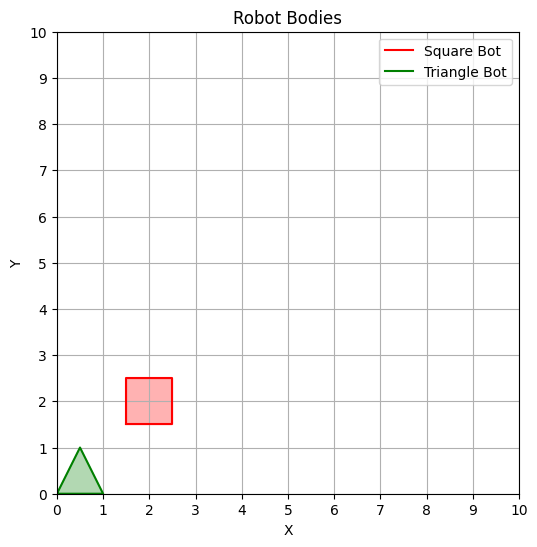

In [4]:
# Provided utilities — do not modify

def create_polygon(vertices):
    """Return an (N, 2) array of polygon vertices."""
    if len(vertices) < 3:
        raise ValueError("A polygon must have at least 3 vertices.")
    return np.array(vertices)


def plot_polygons(polygons, colors=None, labels=None, title="Robot Bodies"):
    """Plot multiple polygons on a 10×10 canvas."""
    plt.figure(figsize=(6, 6))
    for i, poly in enumerate(polygons):
        closed = np.vstack([poly, poly[0]])
        c = colors[i] if colors and i < len(colors) else "blue"
        l = labels[i] if labels and i < len(labels) else f"Polygon {i+1}"
        plt.plot(closed[:, 0], closed[:, 1], color=c, label=l)
        plt.fill(closed[:, 0], closed[:, 1], alpha=0.3, color=c)
    plt.xlim(0, 10); plt.ylim(0, 10)
    plt.xticks(np.arange(0, 11)); plt.yticks(np.arange(0, 11))
    plt.gca().set_aspect("equal"); plt.grid(True)
    plt.xlabel("X"); plt.ylabel("Y"); plt.title(title); plt.legend(); plt.show()


# Example bodies used throughout Task 1
square = create_polygon([(1.5, 1.5), (2.5, 1.5), (2.5, 2.5), (1.5, 2.5)])
triangle = create_polygon([(0, 0), (1, 0), (0.5, 1)])
plot_polygons([square, triangle], colors=["red", "green"], labels=["Square Bot", "Triangle Bot"])

### Task 1.1 — Translation

A translation by $(x_t, y_t)$ maps every point $(x, y) \in A$ to $(x + x_t,\; y + y_t)$.

**Implement** `translate_polygon` below.

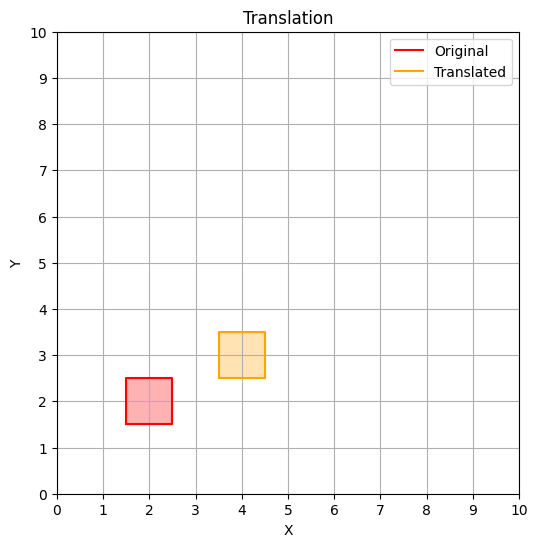

In [5]:
def translate_polygon(polygon, dx, dy):
    """
    Translate a polygon by (dx, dy).

    Parameters
    ----------
    polygon : np.ndarray, shape (N, 2)
    dx, dy  : float
    
    Returns
    -------
    np.ndarray, shape (N, 2)
    """
    # TODO: implement translation
    #raise NotImplementedError
    translation_vector = np.array([dx,dy])
    return polygon + translation_vector


# Test: translate the square by (2, 1)
translated_square = translate_polygon(square, dx=2, dy=1)
plot_polygons([square, translated_square], colors=["red", "orange"],
              labels=["Original", "Translated"], title="Translation")

### Task 1.2 — Rotation

A counterclockwise rotation by $\theta$ is given by:

$$
R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}
$$

Rotation is always performed about the origin.

**Implement** `rotate_polygon` below.

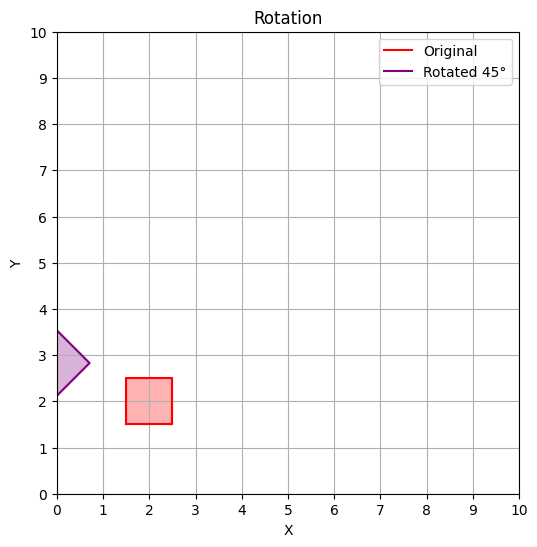

In [6]:
def rotate_polygon(polygon, theta):
    """
    Rotate a polygon counter-clockwise by theta radians around the origin.

    Parameters
    ----------
    polygon : np.ndarray, shape (N, 2)
    theta   : float  — angle in radians

    Returns
    -------
    np.ndarray, shape (N, 2)
    """
    # TODO: build the 2×2 rotation matrix and apply it
    #raise NotImplementedError
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta),  np.cos(theta)]])
    return polygon @ rotation_matrix.T


# Test: rotate the square by 45°
rotated_square = rotate_polygon(square, np.pi / 4)
plot_polygons([square, rotated_square], colors=["red", "purple"],
              labels=["Original", "Rotated 45°"], title="Rotation")

### Task 1.3 — Homogeneous Transformation Matrix

We can chain rotation *and* translation into a single $3\times 3$ matrix:

$$
T = \begin{pmatrix} \cos\theta & -\sin\theta & x_t \\ \sin\theta & \cos\theta & y_t \\ 0 & 0 & 1 \end{pmatrix}
$$

Applied to a point $(x, y)$ extended to $(x, y, 1)$:

$$
T \begin{pmatrix} x \\ y \\ 1 \end{pmatrix} = \begin{pmatrix} x\cos\theta - y\sin\theta + x_t \\ x\sin\theta + y\cos\theta + y_t \\ 1 \end{pmatrix}
$$

**Note:** the rotation is applied first, then the translation. Transformations compose by matrix multiplication — but order matters!

**Implement** `apply_transform` and `create_transform` below.

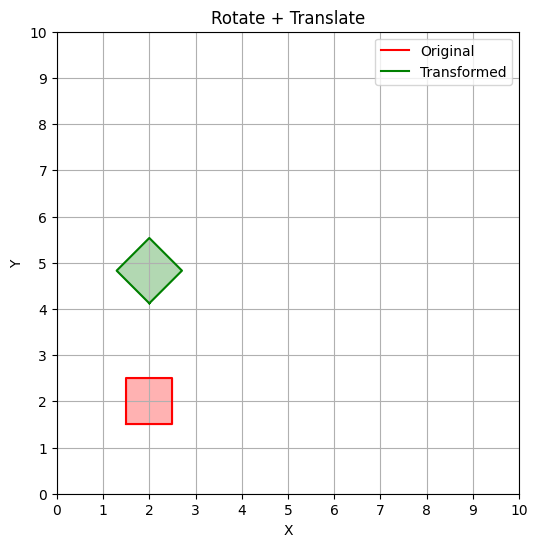

In [7]:
def create_transform(theta, dx, dy):
    """
    Build a 3×3 homogeneous transformation matrix.

    Parameters
    ----------
    theta   : float  — rotation angle in radians
    dx, dy  : float  — translation

    Returns
    -------
    np.ndarray, shape (3, 3)
    """
    # TODO: fill in the matrix entries
    #raise NotImplementedError
    transformed_matrix = np.array([[np.cos(theta), -np.sin(theta), dx],
                                   [np.sin(theta),  np.cos(theta), dy],
                                   [0,              0,             1]])
    return transformed_matrix


def apply_transform(polygon, transform):
    """
    Apply a 3×3 homogeneous transformation to a polygon.

    Parameters
    ----------
    polygon   : np.ndarray, shape (N, 2)
    transform : np.ndarray, shape (3, 3)

    Returns
    -------
    np.ndarray, shape (N, 2)
    """
    # TODO: extend to homogeneous coords, multiply, return (N, 2)
    #raise NotImplementedError
    N = polygon.shape[0]
    polygon_homogeneous = np.hstack([polygon, np.ones((N, 1))])  # (N, 3)
    transformed_homogeneous = polygon_homogeneous @ transform.T  # (N, 3)
    return transformed_homogeneous[:, :2]  # return (N, 2)
 


# Test: rotate 45° and translate by (2, 2)
T = create_transform(np.pi / 4, dx=2, dy=2)
transformed_square = apply_transform(square, T)
plot_polygons([square, transformed_square], colors=["red", "green"],
              labels=["Original", "Transformed"], title="Rotate + Translate")

## Task 2: Kinematic Chains in 2D

<div style="text-align:center">
  <img src="images/joints.png" height="220"/>
  <p><em>Two common 2D joint types: revolute (rotation) and prismatic (translation).</em></p>
</div>

A robot with multiple links has one **body frame** per link. The pose of link $A_{i+1}$ in the world is obtained by composing all transformations along the chain:

$$
T_{\text{world}} = T_1 \cdot T_2 \cdots T_k
$$

(applied right-to-left, i.e. $T_1$ first).

<div style="text-align:center">
  <img src="images/chains.png" width="560"/>
  <p><em>Each link's body frame is defined relative to the joint connecting it to its parent.</em></p>
</div>

### Task 2.1 — Two-Link Arm

**Implement** `draw_two_link_arm`. Given the base length $l_1$, arm length $l_2$, and a joint angle $\theta$:

1. Create $A_1$ as a rectangular polygon centred at the origin, then place it in the world with `T_A1`.
2. Build the transform chain for $A_2$: base world transform → translate to joint at end of $A_1$    → rotate by $\theta$ → translate to link centre of $A_2$.
3. Plot both links.

**Hint:** all transforms compose via matrix multiplication and should be applied using `apply_transform` from Task 1.

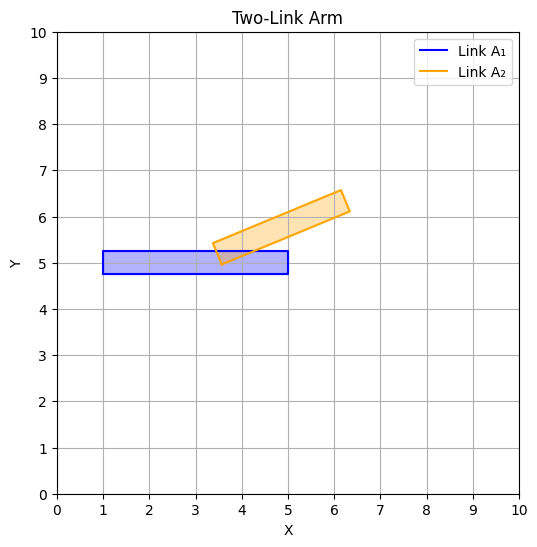

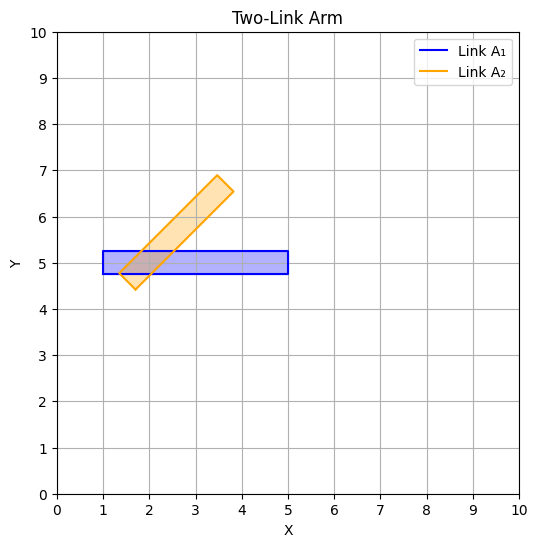

In [8]:
def draw_two_link_arm(base_length, arm_length, joint_angle):
    """
    Visualise a 2-link planar arm with one revolute joint.

    Parameters
    ----------
    base_length : float  — length of link A₁
    arm_length  : float  — length of link A₂
    joint_angle : float  — rotation of A₂ relative to A₁ (radians)
    """
    height = 0.5  # link thickness

    # TODO:
    #  1. Create A₁ (rectangle centred at origin) and define T_A1
    #     (e.g. place the base at world position (3, 5))
    #  2. Apply T_A1 to get A₁ in world coordinates
    #  3. Create A₂ (rectangle centred at origin)
    #  4. Build the full transform chain for A₂ and apply it
    #  5. Call plot_polygons to visualise

    #raise NotImplementedError
    polygon_A1 = create_polygon([(-base_length/2, -height/2), (base_length/2, -height/2),
                               (base_length/2, height/2), (-base_length/2, height/2)])
    
    T_A1 = create_transform(0, dx=3, dy=5)

    A1_world = apply_transform(polygon_A1, T_A1)

    polygon_A2 = create_polygon([(-arm_length/2, -height/2), (arm_length/2, -height/2),
                               (arm_length/2, height/2), (-arm_length/2, height/2)])
    
    T_A2 = create_transform(joint_angle, dx=base_length, dy=0) @ T_A1 
     # first rotate, then translate by base_length along A₁
    A2_world = apply_transform(polygon_A2, T_A2)

    plot_polygons([A1_world, A2_world], colors=["blue", "orange"], labels=["Link A₁", "Link A₂"], title="Two-Link Arm")
    


draw_two_link_arm(base_length=4.0, arm_length=3.0, joint_angle=np.pi / 8)
draw_two_link_arm(base_length=4.0, arm_length=3.0, joint_angle=np.pi / 4)

## Task 3: Grid-Based Obstacle Mapping

<div style="text-align:center">
  <img src="images/maps.png" width="480"/>
  <p><em>Lossy discretisation of a continuous environment into an occupancy grid. From <em>Autonomous Mobile Robots</em>, Siegwart et al.</em></p>
</div>

An **occupancy grid** represents the environment as a 2D array of discrete cells, each marked as free (0) or occupied (1). This converts the path-planning problem into graph search.

Key design choices:
- **Resolution** — cell size in metres (smaller = more accurate, slower planning)
- **Connectivity** — 4-connected (cardinal) or 8-connected (including diagonals)

### Task 3.1 — GridMap class

Implement a `GridMap` that can be initialised with a width, height, and resolution, mark cells as obstacles, check if a cell is free, and visualise the grid.

In [ ]:
from shapely.geometry import Polygon as ShapelyPolygon, Point

class GridMap:
    def __init__(self, width, height, resolution=1.0):
        """
        Initialise a 2D occupancy grid.

        Parameters
        ----------
        width, height : int    — grid dimensions in cells
        resolution    : float  — metres per cell
        """
        self.width = width
        self.height = height
        self.resolution = resolution
        # numpy arrays are indexed [row, col] = [y, x], so shape is (height, width)
        self.grid = np.zeros((height, width), dtype=np.uint8)

    def set_obstacle(self, x, y):
        """Mark cell (x, y) as occupied."""
        if 0 <= x < self.width and 0 <= y < self.height:
            self.grid[y, x] = 1

    def is_free(self, x, y):
        """Return True if cell (x, y) is within bounds and unoccupied."""
        if not (0 <= x < self.width and 0 <= y < self.height):
            return False
        return self.grid[y, x] == 0

    def visualize(self, path=None, robot_pos=None, title="Grid Map"):
        """
        Display the grid, optionally overlaying a path and robot position.

        Parameters
        ----------
        path      : list of (x, y) cells, optional
        robot_pos : (x, y) cell, optional
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(self.grid, cmap="Greys", origin="lower")
        if path:
            px, py = zip(*path)
            ax.plot(px, py, "b-o", ms=4, lw=2, label="path")
        if robot_pos:
            ax.plot(robot_pos[0], robot_pos[1], "ro", ms=10, label="robot")
        ax.set_xticks(np.arange(-0.5, self.width, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.height, 1), minor=True)
        ax.grid(which="minor", color="lightgray", linewidth=0.8)
        ax.tick_params(which="minor", size=0)
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title(title)
        if path or robot_pos: ax.legend()
        plt.show()


# Quick test
gm = GridMap(10, 10, 1.0)
for y in range(10): gm.set_obstacle(5, y)  # vertical wall
gm.visualize(title="Vertical wall")
print("is_free(4, 4):", gm.is_free(4, 4))   # True
print("is_free(5, 4):", gm.is_free(5, 4))   # False

### Task 3.2 — Rasterise Polygon Obstacles

Given a polygonal obstacle (as a `shapely.geometry.Polygon`), we can populate the grid by checking whether the centre of each cell falls inside the polygon.

**Implement** `add_polygon_obstacle_to_grid`.

In [ ]:
def add_polygon_obstacle_to_grid(gridmap, polygon):
    """
    Mark all cells whose centre falls inside `polygon` as obstacles.

    Parameters
    ----------
    gridmap : GridMap
    polygon : shapely.geometry.Polygon
    """
    for iy in range(gridmap.height):
        for ix in range(gridmap.width):
            # Cell (ix, iy) covers [ix*res, (ix+1)*res] x [iy*res, (iy+1)*res]
            # Its centre is offset by half a cell from the lower-left corner.
            cx = (ix + 0.5) * gridmap.resolution
            cy = (iy + 0.5) * gridmap.resolution
            if polygon.contains(Point(cx, cy)):
                gridmap.set_obstacle(ix, iy)


# Test on a 5 m × 5 m scene
gm2 = GridMap(50, 50, 0.1)
obstacles = [
    ShapelyPolygon([(2.0, 2.0), (2.5, 2.0), (2.5, 2.5), (2.0, 2.5)]),
    ShapelyPolygon([(1.0, 3.0), (1.5, 4.0), (2.0, 3.0)]),
    ShapelyPolygon([(3.0, 3.0), (4.0, 3.0), (4.0, 3.5), (3.5, 3.5), (3.5, 4.0), (3.0, 4.0)]),
]
for obs in obstacles:
    add_polygon_obstacle_to_grid(gm2, obs)
gm2.visualize(title="Polygon obstacles rasterised")

## Task 4: A* Path Planning

<div style="text-align:center">
  <img src="images/robot_astar.gif" width="420"/>
  <p><em>A* expanding cells on an 8-connected grid. From <a href="https://fab.cba.mit.edu/classes/865.21/topics/path_planning/robotic.html">MIT 865.21</a>.</em></p>
</div>

A* maintains a priority queue ordered by $f(n) = g(n) + h(n)$, where:
- $g(n)$ — cost from start to $n$
- $h(n)$ — admissible heuristic estimate of cost from $n$ to goal

For a 4-connected uniform-cost grid, the **Manhattan distance** is a natural admissible heuristic.

A* is *resolution-complete*: it finds a path if one exists at the chosen grid resolution.

### Think about
- What changes with 8-connected neighbours?
- When is Manhattan distance inadmissible?
- How can the cell cost be used to keep the robot away from walls?

### Task 4.1 — Implement A*

**Implement** `a_star`. Use a min-heap (`heapq`) for the priority queue and return the list of `(x, y)` cells from start to goal, or `None` if no path exists.

In [ ]:
def heuristic(a, b):
    """Manhattan distance between cells a and b."""
    # TODO
    raise NotImplementedError


def a_star(gridmap, start, goal):
    """
    A* search on a GridMap.

    Parameters
    ----------
    gridmap : GridMap
    start   : (x, y) — start cell
    goal    : (x, y) — goal cell

    Returns
    -------
    list of (x, y) cells (including start and goal), or None
    """
    # TODO:
    #  - initialise priority queue with (f, g, start, path=[])
    #  - expand neighbours in 4-connected grid
    #  - skip occupied or out-of-bounds cells
    #  - return path when goal is reached
    raise NotImplementedError


# Test on a simple 20×20 map with a vertical wall
gm3 = GridMap(20, 20, 1.0)
for y in range(5, 15):
    gm3.set_obstacle(10, y)

start, goal = (2, 10), (17, 10)
path = a_star(gm3, start, goal)
print("Path length:", len(path) if path else "No path found")
gm3.visualize(path=path, title="A* result")

**Answer the following questions in the cell below** (plain text or markdown):
1. What happens to the explored area if you switch to 8-connected neighbours?
2. Give an example of a scenario where Manhattan distance would be inadmissible.
3. How would you modify the cost function to bias the robot away from walls?

*Your answers here.*

## Task 5: Navigation in MuJoCo with TAMPanda

We now bring the grid planner into a full physics simulation.

TAMPanda's `AStarNav` builds a properly inflated occupancy grid directly from MuJoCo scene geometry (Minkowski sum of each obstacle with the robot's footprint). In the course stub branch, `AStarNav.plan()` raises `NotImplementedError` — your job is to implement A* that searches this grid.

The planner exposes everything you need:

| Method / property | Description |
|---|---|
| `planner.is_free(ix, iy)` | True if cell is free |
| `planner._world_to_grid(x, y)` | World coords → grid indices `(ix, iy)` |
| `planner._grid_to_world(ix, iy)` | Grid indices → world coords `(x, y)` |
| `planner.grid_shape()` | `(nx, ny)` |
| `planner.smooth_path(path)` | Line-of-sight pruner (provided) |
| `planner.to_image()` | `(ny, nx)` uint8 image for visualisation |

Rendering helpers (provided — do not modify):

In [ ]:
def show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=110)
    buf.seek(0); display(Image(buf.read())); plt.close(fig)


def render_top(env, lookat=(1.5, 0.0, 0.3), distance=5.5, width=640, height=360):
    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(env.model, cam)
    cam.lookat[:] = lookat; cam.distance = distance
    cam.azimuth = 0.0; cam.elevation = -70.0
    r = mujoco.Renderer(env.model, height=height, width=width)
    r.update_scene(env.data, camera=cam)
    img = r.render(); r.close()
    return img

### Task 5.1 — Build a Scene

Use `MobileSceneBuilder` to create a navigation scene with at least **two walls** that force the robot to take a non-trivial path. Place walls with `WALL_TEMPLATE`; use `euler=[0, 0, 90]` to orient them perpendicular to the corridor.

In [ ]:
from tampanda import MobileSceneBuilder, MobileEnvironment, DifferentialDriveController, AStarNav
from tampanda.scenes import WALL_TEMPLATE

builder = MobileSceneBuilder()
builder.add_resource("wall", WALL_TEMPLATE)

# TODO: add at least two walls that force a non-trivial path
# Example:
# builder.add_object("wall", pos=[1.2, -1.0, 0.30], euler=[0, 0, 90], name="wall_a0")
# builder.add_object("wall", pos=[1.2, -0.1, 0.30], euler=[0, 0, 90], name="wall_a1")
# builder.add_object("wall", pos=[2.4,  0.1, 0.30], euler=[0, 0, 90], name="wall_b0")
# builder.add_object("wall", pos=[2.4,  1.0, 0.30], euler=[0, 0, 90], name="wall_b1")

env = builder.build_env(env_class=MobileEnvironment, rate=1_000_000)
env.set_pose(0.0, 0.0, 0.0)
env.data.qvel[:] = 0.0; env.data.ctrl[:] = 0.0
mujoco.mj_forward(env.model, env.data)

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(render_top(env)); ax.axis("off"); ax.set_title("Your scene — top view")
show_fig(fig)

### Task 5.2 — Build and Inspect the Occupancy Grid

Create an `AStarNav` planner — this automatically builds the geometry-based, robot-radius-inflated occupancy grid from the MuJoCo scene. Visualise the result before implementing A*.

In [ ]:
X_RANGE    = (-0.5, 4.0)
Y_RANGE    = (-2.0, 2.0)
RESOLUTION = 0.06

planner = AStarNav(
    env,
    x_range=X_RANGE,
    y_range=Y_RANGE,
    resolution=RESOLUTION,
    robot_radius_buffer=0.05,
)

# Visualise the grid
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(planner.to_image(), origin="lower", cmap="Greys_r",
          extent=[X_RANGE[0], X_RANGE[1], Y_RANGE[0], Y_RANGE[1]])
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title(f"Occupancy grid — {planner.grid_shape()[0]}×{planner.grid_shape()[1]} cells "
             f"(resolution={RESOLUTION} m, includes robot-radius inflation)")
show_fig(fig)

### Task 5.3 — Implement A* on the Planner Grid

Implement `my_plan(planner, start, goal)` — this is the function that mirrors the `AStarNav.plan()` stub in the course branch of TAMPanda.

Use `planner.is_free(ix, iy)` for collision checks, `planner._world_to_grid(x, y)` to convert start/goal, and `planner._grid_to_world(ix, iy)` to convert the path back to world coordinates.

The planner uses an **8-connected grid** with diagonal cost $\sqrt{2}$. Use the **octile heuristic** for consistency:

$$h(n) = \max(|\Delta x|, |\Delta y|) + (\sqrt{2} - 1) \cdot \min(|\Delta x|, |\Delta y|)$$

In [ ]:
def my_plan(planner, start, goal):
    """
    A* search on the AStarNav occupancy grid.

    Parameters
    ----------
    planner : AStarNav  — provides is_free(), _world_to_grid(), _grid_to_world()
    start   : (x, y)   — world-frame start position
    goal    : (x, y)   — world-frame goal position

    Returns
    -------
    List of (x, y) world-frame waypoints from start to goal, or None.
    """
    gs = planner._world_to_grid(*start)
    gg = planner._world_to_grid(*goal)

    if not planner.is_free(*gs):
        print(f"Start {start} is in collision."); return None
    if not planner.is_free(*gg):
        print(f"Goal {goal} is in collision."); return None

    # TODO:
    #  1. Define the octile heuristic h(ix, iy)
    #  2. Initialise a min-heap with (f, g, node=(ix,iy))
    #  3. Maintain g_cost dict and came_from dict
    #  4. Expand 8-connected neighbours (dx, dy, cost) where
    #     cardinal cost = 1.0, diagonal cost = √2 ≈ 1.414
    #  5. When goal is reached, reconstruct the path and convert
    #     each grid cell back to world coords with _grid_to_world
    raise NotImplementedError


# Test
START = (0.0, 0.0)
GOAL  = (3.4, 0.0)

raw_path = my_plan(planner, START, GOAL)
if raw_path is None:
    print("No path found — check scene layout or grid bounds.")
else:
    smooth = planner.smooth_path(raw_path)
    print(f"Raw: {len(raw_path)} waypoints → Smoothed: {len(smooth)} waypoints")

    # Visualise
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(planner.to_image(), origin="lower", cmap="Greys_r",
              extent=[X_RANGE[0], X_RANGE[1], Y_RANGE[0], Y_RANGE[1]])
    rx, ry = zip(*raw_path)
    sx, sy = zip(*smooth)
    ax.plot(rx, ry, "b-", lw=1, alpha=0.4, label=f"raw ({len(raw_path)} pts)")
    ax.plot(sx, sy, "r-o", ms=6, lw=2, label=f"smoothed ({len(smooth)} pts)")
    ax.plot(*START, "g^", ms=12, label="start"); ax.plot(*GOAL, "r*", ms=14, label="goal")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.legend(); ax.set_title("A* path")
    show_fig(fig)

### Task 5.4 — Execute the Path

Use `DifferentialDriveController.follow_waypoints` to drive the robot along the smoothed path. The smoothed path from `planner.smooth_path()` typically reduces hundreds of raw waypoints to fewer than 15, which the controller can track reliably.

In [ ]:
if raw_path is not None:
    ctrl = DifferentialDriveController(env.get_model(), env.get_data())
    env.set_pose(*START, 0.0)
    env.data.qvel[:] = 0.0; env.data.ctrl[:] = 0.0
    mujoco.mj_forward(env.model, env.data)

    print(f"Executing {len(smooth)} waypoints...")
    ok = ctrl.follow_waypoints(
        smooth, env,
        final_theta=0.0,
        linear_speed=0.4,
        angular_speed=1.2,
        position_tol=0.12,
    )
    x, y, theta = env.get_pose()
    err = np.hypot(x - GOAL[0], y - GOAL[1])
    print(f"Navigation {'succeeded' if ok else 'FAILED'}")
    print(f"Final pose: x={x:.3f} m, y={y:.3f} m — goal error: {err*100:.1f} cm")

### Task 5.5 — Lidar-Based Grid

The approach above uses geometry to build the grid. Real robots don't have access to the ground-truth scene description — they must build the map from sensor data.

Use `Lidar` to scan the environment from the robot's starting position and build a `GridMap` (from Task 3) from the raw Lidar hits. Then run your A* on that grid and compare the resulting path to the geometry-based one.

**Questions to consider:**
1. Where does the Lidar-based grid agree with the geometry-based one? Where does it differ?
2. What happens near wall faces that are parallel to the ray directions?
3. How would you make the Lidar grid more robust (multiple scan positions, ray dilation, etc.)?

In [ ]:
from tampanda import Lidar

lidar = Lidar(env, site="lidar_site", num_rays=360, fov_h=360.0,
              range_max=6.0, body_exclude="base_link")

# TODO: scan and populate a GridMap, run A*, visualise side-by-side with the geometry grid
# Hint: use the same X_RANGE, Y_RANGE, RESOLUTION for fair comparison

### Reflection Questions

1. Why does `AStarNav` build the grid from geometry rather than Lidar?
2. What does the `robot_radius_buffer` parameter do, and why is it necessary?
3. Your A* uses an 8-connected grid with the octile heuristic.    Would a 4-connected grid with Manhattan distance find the same paths?    When would they differ?

*Your answers here.*

## Submission Checklist

- [ ] Task 0: TAMPanda installed and verified
- [ ] Task 1.1: `translate_polygon` implemented and tested
- [ ] Task 1.2: `rotate_polygon` implemented and tested
- [ ] Task 1.3: `create_transform` and `apply_transform` implemented and tested
- [ ] Task 2.1: `draw_two_link_arm` implemented for at least two joint angles
- [ ] Task 3.1: `GridMap` implemented and tested
- [ ] Task 3.2: `add_polygon_obstacle_to_grid` implemented
- [ ] Task 4.1: `a_star` implemented and tested on a 2D GridMap
- [ ] Task 4 questions answered
- [ ] Task 5.1: Scene built with at least two walls
- [ ] Task 5.2: Occupancy grid visualised
- [ ] Task 5.3: `my_plan` implemented and path visualised
- [ ] Task 5.4: Path executed successfully in MuJoCo
- [ ] Task 5 reflection questions answered
- [ ] Task 5.5 (bonus): Lidar grid built and compared